# Player Eda Tests

### Imports and settings

In [1]:
import pandas as pd                                                    # tables
import numpy as np                                                     # maths
import matplotlib.pyplot as plt                                        # charts
import seaborn as sns                                                  # nicer charts
from scipy import stats                                                # statistical tests
from statsmodels.stats.multitest import multipletests                  # Holm correction
from pathlib import Path                                               # file paths

sns.set_theme(style="whitegrid")                                       # chart style
pd.set_option("display.max_columns", None)                             # never hide columns
pd.set_option("display.width", 200)                                    # wide printing

### Paths and data

In [2]:
ROOT = Path.cwd()                                                      # folder the notebook runs in
if ROOT.name == "notebooks":                                           # if inside notebooks/...
    ROOT = ROOT.parent                                                 # ...go up to the project root
DATA = ROOT / "data" / "processed"                                     # data folder
FIG = ROOT / "reports" / "figures"                                     # charts folder
players = pd.read_csv(DATA / "player_features.csv", parse_dates=["cohort_date"])   # one row per new player
players["churned_7d"] = 1 - players["returned_within_7d"]              # 1 = did NOT come back within 7 days
print(players.shape)                                                   # rows and columns
print("Churn rate (no return within 7 days):", round(players["churned_7d"].mean(), 4))   # overall label balance

(11066, 29)
Churn rate (no return within 7 days): 0.7135


### Data quality checks

In [3]:
print("Duplicate player ids:", players["player_id"].duplicated().sum())                 # expect 0
print("Missing values per column:"); print(players.isna().sum()[players.isna().sum() > 0])   # columns with any missing values
numeric_cols = [c for c in players.columns if c.startswith("d0_")]                       # all day-0 behaviour features
print("Negative values:", int((players[numeric_cols] < 0).sum().sum()))                  # counts can never be negative
print("Unknown country share:", round((players["country"] == "(unknown)").mean(), 4))   # placeholder share
print("Players with fewer than 2 engaged minutes on day 0:", round((players["d0_engaged_minutes"] < 2).mean(), 4))   # light first days

Duplicate player ids: 0
Missing values per column:
Series([], dtype: int64)
Negative values: 0
Unknown country share: 0.001
Players with fewer than 2 engaged minutes on day 0: 0.4288


### Compare mean vs median and skewness

In [4]:
shape = pd.DataFrame({
    "mean": players[numeric_cols].mean(),                              # average
    "median": players[numeric_cols].median(),                          # middle value
    "p90": players[numeric_cols].quantile(0.9),                        # heavy players
    "skewness": players[numeric_cols].skew(),                          # > 1 means strongly right-skewed
}).round(2)
print(shape.sort_values("skewness", ascending=False))                  # most skewed first

                          mean  median    p90  skewness
d0_ad_rewards             0.03    0.00   0.00     31.70
d0_levels_reset           1.01    0.00   2.00     30.56
d0_friend_challenges      0.02    0.00   0.00     22.34
d0_levels_completed       0.97    0.00   2.00     14.06
d0_levels_started         4.07    1.00   9.00     13.40
d0_levels_ended           2.47    0.00   6.00     12.04
d0_extra_steps_used       0.28    0.00   1.00      9.05
d0_currency_spends        0.31    0.00   1.00      8.84
d0_engaged_minutes        7.09    2.61  16.76      7.14
d0_scores_posted          2.54    1.00   7.00      6.39
d0_engagement_events     18.49    9.00  42.00      5.98
d0_avg_session_minutes    8.00    3.87  19.27      4.75
d0_sessions               1.23    1.00   2.00      3.89
d0_completed_5_levels     0.10    0.00   0.00      3.14
d0_distinct_event_types   8.70    8.00  14.00      0.63


### Chart: key behaviours for returners vs churners (log scale)

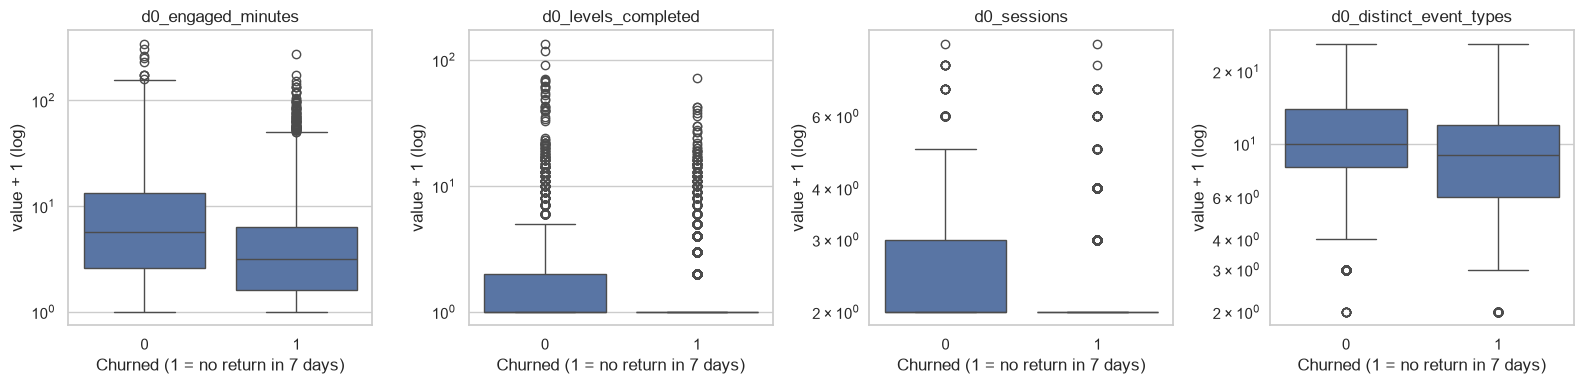

In [5]:
plot_cols = ["d0_engaged_minutes", "d0_levels_completed", "d0_sessions", "d0_distinct_event_types"]   # four key features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))                        # four small charts
for ax, col in zip(axes, plot_cols):                                   # one loop, one chart per feature
    sns.boxplot(data=players, x="churned_7d", y=players[col] + 1, log_scale=True, ax=ax)   # +1 so zeros work on a log scale
    ax.set_title(col)                                                  # feature name
    ax.set_xlabel("Churned (1 = no return in 7 days)")                 # x label
    ax.set_ylabel("value + 1 (log)")                                   # y label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "07_features_by_churn.png", dpi=150)                 # save
plt.show()                                                             # display

### Mann-Whitney U tests with effect sizes and Holm correction

In [6]:
rows = []                                                              # results collector
returned = players[players["churned_7d"] == 0]                          # players who came back
churned = players[players["churned_7d"] == 1]                          # players who did not
for col in numeric_cols:                                               # one loop, one feature per iteration
    test = stats.mannwhitneyu(returned[col], churned[col], alternative="two-sided")   # rank-based test (robust to skew)
    prob_superiority = test.statistic / (len(returned) * len(churned))  # chance a random returner has a higher value than a random churner
    rows.append({"feature": col,
                 "median_returned": returned[col].median(),
                 "median_churned": churned[col].median(),
                 "prob_superiority": prob_superiority,
                 "rank_biserial": 2 * prob_superiority - 1,             # effect size from -1 to +1
                 "p_value": test.pvalue})
tests = pd.DataFrame(rows)                                             # to table
tests["p_holm"] = multipletests(tests["p_value"], method="holm")[1]    # correct for testing many features at once
tests = tests.sort_values("rank_biserial", key=np.abs, ascending=False)   # biggest effects first
print(tests.round(4).to_string(index=False))                           # show

                feature  median_returned  median_churned  prob_superiority  rank_biserial  p_value  p_holm
     d0_engaged_minutes            4.655            2.13            0.6434         0.2869   0.0000  0.0000
 d0_avg_session_minutes            5.920            3.42            0.6348         0.2696   0.0000  0.0000
   d0_engagement_events           13.000            8.00            0.6296         0.2592   0.0000  0.0000
       d0_scores_posted            1.000            0.00            0.6184         0.2369   0.0000  0.0000
d0_distinct_event_types            9.000            8.00            0.6045         0.2090   0.0000  0.0000
        d0_levels_ended            1.000            0.00            0.5882         0.1764   0.0000  0.0000
            d0_sessions            1.000            1.00            0.5868         0.1735   0.0000  0.0000
      d0_levels_started            2.000            1.00            0.5824         0.1649   0.0000  0.0000
    d0_levels_completed            0.

### Categorical features: chi-square test and Cramer's V

In [7]:
for col in ["platform", "cohort_day_of_week"]:                         # one loop, one categorical feature per iteration
    table = pd.crosstab(players[col], players["churned_7d"])           # counts: category x churned
    chi2, p, dof, _ = stats.chi2_contingency(table)                    # independence test
    cramers_v = np.sqrt(chi2 / (table.to_numpy().sum() * (min(table.shape) - 1)))   # effect size from 0 to 1
    rates = players.groupby(col)["churned_7d"].mean().round(4)         # churn rate per category
    print(f"\n{col}: chi2 = {chi2:.2f}, dof = {dof}, p = {p:.4g}, Cramer's V = {cramers_v:.3f}")   # test summary
    print(rates.to_string())                                           # rates


platform: chi2 = 2.04, dof = 1, p = 0.1535, Cramer's V = 0.014
platform
ANDROID    0.7073
IOS        0.7197

cohort_day_of_week: chi2 = 38.31, dof = 6, p = 9.769e-07, Cramer's V = 0.059
cohort_day_of_week
1    0.7461
2    0.6904
3    0.7051
4    0.6803
5    0.7109
6    0.6990
7    0.7561


### Spearman correlation heatmap (rank correlation handles skewed counts)

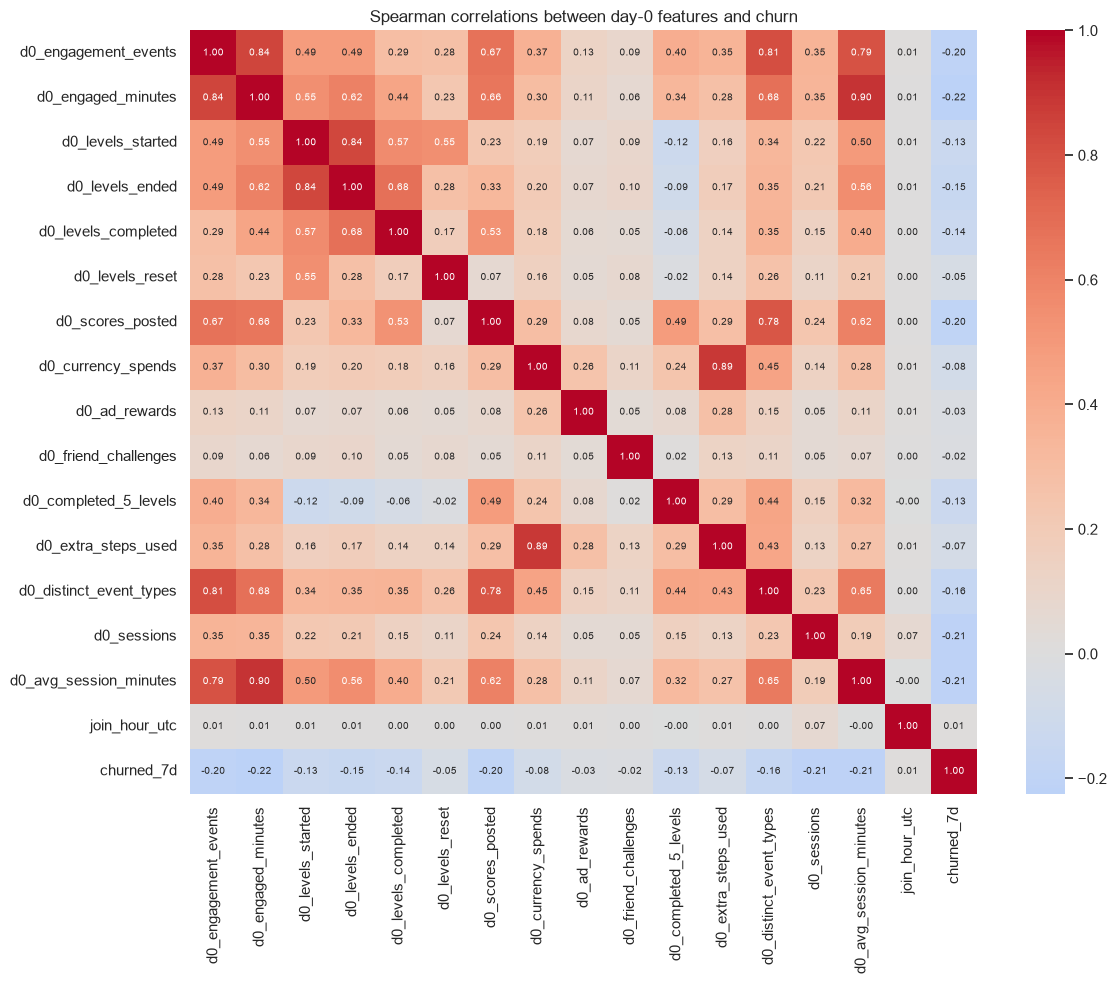

Feature pairs with |rho| > 0.8 (redundant information):
d0_engagement_events  d0_engaged_minutes         0.844
                      d0_distinct_event_types    0.810
d0_engaged_minutes    d0_avg_session_minutes     0.899
d0_levels_started     d0_levels_ended            0.840
d0_currency_spends    d0_extra_steps_used        0.888


In [8]:
corr_cols = numeric_cols + ["join_hour_utc", "churned_7d"]             # features plus the label
corr = players[corr_cols].corr(method="spearman")                      # rank-based correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))                               # empty chart
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)   # coloured matrix
ax.set_title("Spearman correlations between day-0 features and churn")   # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "08_spearman_correlations.png", dpi=150)             # save
plt.show()                                                             # display
high_pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()   # every pair once
print("Feature pairs with |rho| > 0.8 (redundant information):")       # heading
print(high_pairs[high_pairs.abs() > 0.8].round(3).to_string())         # strongly related pairs

### Level completion rate vs return rate (descriptive)

                 players  return_rate
completion_band                      
(-0.001, 0.25]      4911       0.2869
(0.25, 0.5]         1234       0.3582
(0.5, 0.75]          487       0.3655
(0.75, 1.0]          761       0.3390


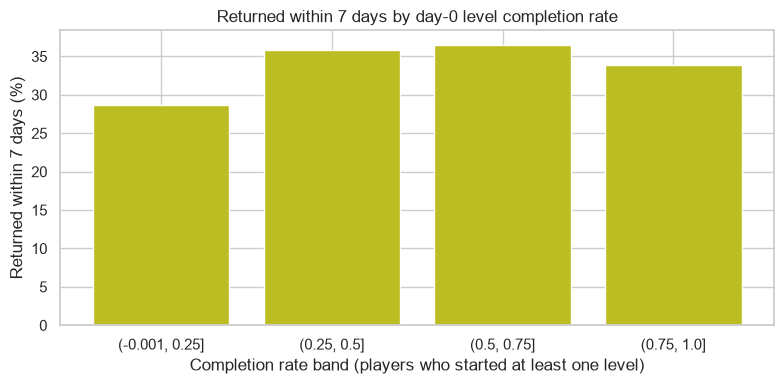

In [9]:
players["d0_completion_rate"] = np.where(players["d0_levels_started"] > 0, players["d0_levels_completed"] / players["d0_levels_started"], np.nan)   # share of started levels completed
bins = [0, 0.25, 0.5, 0.75, 1.0]                                       # completion-rate bands
players["completion_band"] = pd.cut(players["d0_completion_rate"], bins=bins, include_lowest=True)   # assign bands
band = players.groupby("completion_band", observed=True).agg(players=("player_id", "count"), return_rate=("returned_within_7d", "mean"))   # rate per band
print(band.round(4))                                                   # table
fig, ax = plt.subplots(figsize=(8, 4))                                 # empty chart
ax.bar(band.index.astype(str), 100 * band["return_rate"], color="tab:olive")   # bars
ax.set_title("Returned within 7 days by day-0 level completion rate")   # title
ax.set_xlabel("Completion rate band (players who started at least one level)")   # x label
ax.set_ylabel("Returned within 7 days (%)")                            # y label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "09_completion_rate_vs_return.png", dpi=150)         # save
plt.show()                                                             # display

### Save the test results

In [10]:
tests.to_csv(DATA / "feature_tests.csv", index=False)                  # for the README and memo
print("Saved feature_tests.csv")                                       # confirm

Saved feature_tests.csv
